In [ ]:
%pip install yfinance

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

# downloading stock data from yfinance

In [3]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META"]
data = yf.download(tickers, start="2010-01-01", end="2024-01-01", interval="1d")["Close"]


[*********************100%***********************]  5 of 5 completed


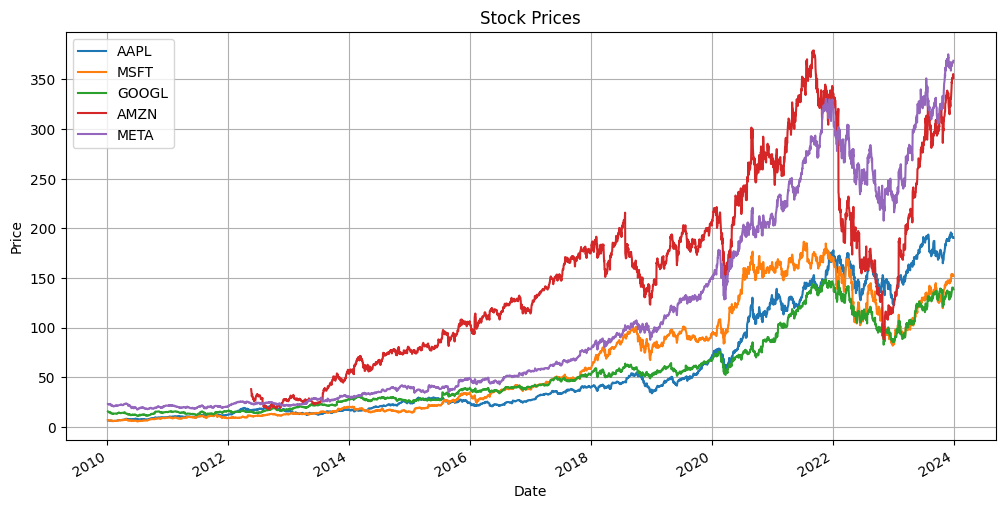

In [4]:
data.plot(figsize=(12, 6), grid=True)
plt.title("Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(tickers)
plt.show()


[*********************100%***********************]  2 of 2 completed


<Axes: title={'center': 'SPY and BND Price Series'}, xlabel='Date', ylabel='Price'>

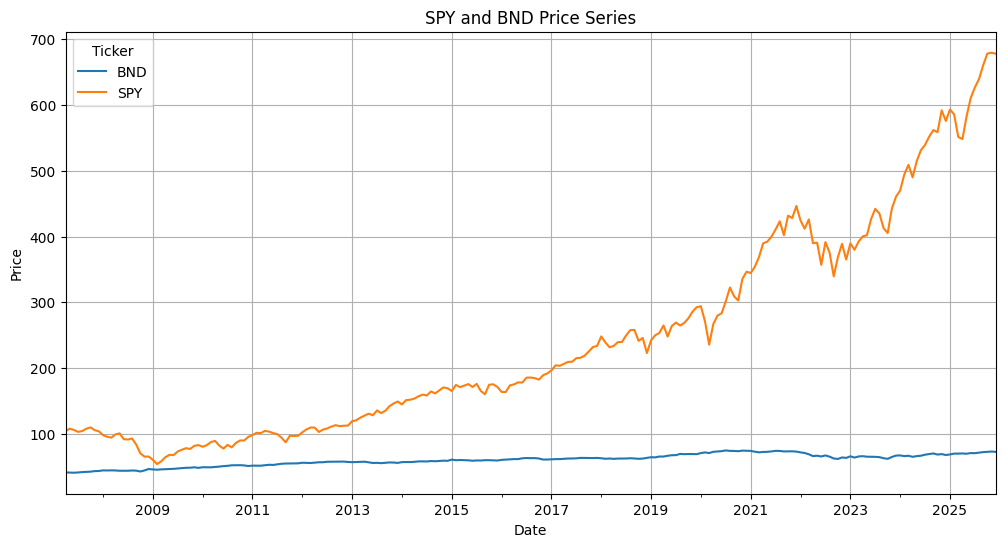

In [5]:
spy_and_bnd = yf.download(tickers=["SPY", "BND"], interval="1mo", start="2001-01-01", end="2026-01-01")["Close"]
spy_and_bnd.dropna(inplace=True)
spy_and_bnd = spy_and_bnd.to_period("M")

spy_and_bnd.plot(figsize=(12, 6), grid=True, title="SPY and BND Price Series", ylabel="Price", xlabel="Date")


#Price series

# Compound Return

$$
R_{t_1,t_3} = (1 + R_{t_1,t_2})(1 + R_{t_2,t_3}) - 1
$$

# Compound returns are NOT additive

In [6]:
#convert prices to returns 

returns = spy_and_bnd.pct_change().dropna()

compound_returns = (1 + returns).prod() - 1
(compound_returns*100).round(2).astype(str) + '%'

Ticker
BND     75.03%
SPY    549.55%
dtype: object

# Variance

$$
Var = \sigma^2 = \frac{1}{N} \sum_{i=1}^{N} (R_i - \mu)^2
$$

## Standard Deviation - Square Root of Variance

$$
\sigma = \sqrt{Var}
$$

In [7]:
returns.std()

Ticker
BND    0.013474
SPY    0.045346
dtype: float64

# Annualized Returns

Annualized return converts a total compounded return into an average yearly return.

First, compound all periodic returns:

$$
R_{total} = \prod_{i=1}^{N}(1 + R_i) - 1
$$

Then convert it to a yearly rate:

$$
R_{annual} = (1 + R_{total})^{\frac{P}{N}} - 1
$$

Where $P$ is the number of periods per year, for example $12$ for monthly returns.

In [8]:
#What constant yearly return would give me the same total return over this period?

def annualized_returns(returns, periods_per_year=12):
    n = returns.shape[0]
    compound_return = (1 + returns).prod()
    return compound_return**(periods_per_year/n) - 1


annualized_returns(returns)

Ticker
BND    0.030443
SPY    0.105434
dtype: float64

# Annualized Volatility

Volatility is measured by the standard deviation of returns.

If returns are monthly, we annualize volatility by multiplying by the square root of 12:

$$
\sigma_{annual} = \sigma_{monthly} \sqrt{12}
$$

This works because variance grows linearly over time:

$$
Var_{annual} = 12 \cdot Var_{monthly}
$$

Since volatility is the square root of variance:

$$
\sigma_{annual} = \sqrt{12 \cdot \sigma_{monthly}^2}
= \sigma_{monthly}\sqrt{12}
$$

In [9]:

def annualized_volatility(returns, periods_per_year=12):
    return returns.std() * np.sqrt(periods_per_year)

# Raw Sharpe Ratio

The raw Sharpe ratio measures return per unit of risk.

$$
\text{Raw Sharpe Ratio} = \frac{R_{annual}}{\sigma_{annual}}
$$

It divides annualized return by annualized volatility.

A higher value means the investment earned more return for each unit of risk.

This is called "raw" because it does not subtract the risk-free rate.

In [10]:
#raw sharpe ratio measures how much return you get per unit of risk
annualized_returns(returns) / annualized_volatility(returns)

Ticker
BND    0.652207
SPY    0.671206
dtype: float64

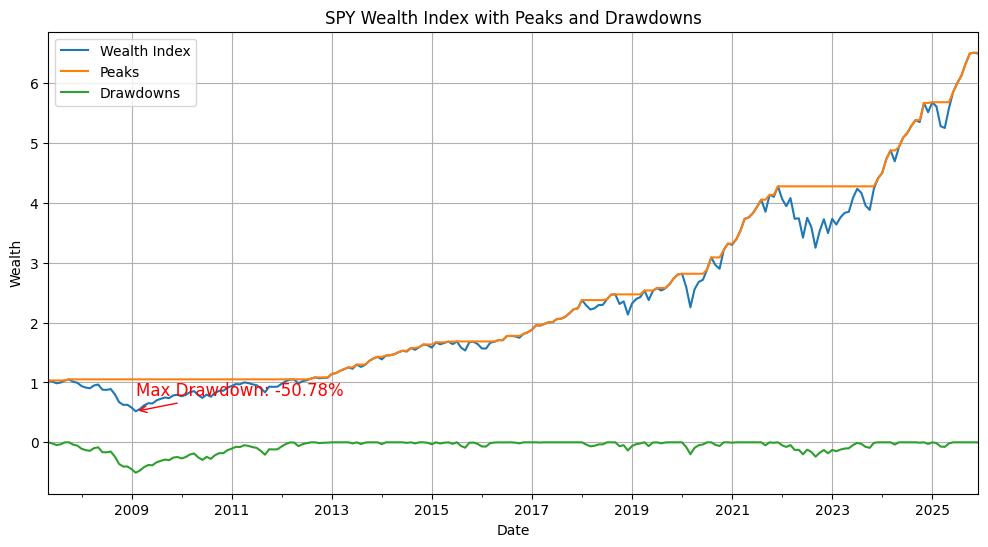

In [11]:
wealth_index = (1 + returns).cumprod()
start_date = wealth_index.index.min()
wealth_index = pd.concat([pd.DataFrame(1, index=[start_date], columns=wealth_index.columns), wealth_index])

peaks = wealth_index.cummax()
drawdowns = (wealth_index - peaks) / peaks

max_drawdown = drawdowns["SPY"].min()
max_drawdown_date = drawdowns["SPY"].idxmin()

wealth_index["SPY"].plot(figsize=(12, 6))



plt.plot(peaks["SPY"])
plt.plot(drawdowns["SPY"])

plt.annotate(f'Max Drawdown: {max_drawdown:.2%}', xy=(max_drawdown_date, wealth_index.loc[max_drawdown_date, "SPY"]), 
             xytext=(max_drawdown_date, wealth_index.loc[max_drawdown_date, "SPY"]*1.5), 
             arrowprops=dict(arrowstyle='->', color='red'), fontsize=12, color='red')

plt.legend(["Wealth Index", "Peaks", "Drawdowns"])
plt.title("SPY Wealth Index with Peaks and Drawdowns")
plt.xlabel("Date")
plt.ylabel("Wealth")
plt.grid()
plt.show()